In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import time
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

In [2]:

TRAIN_DIR = "archive/asl_alphabet_train/asl_alphabet_train"  
TEST_DIR = "archive/asl_alphabet_test/asl_alphabet_test"   

IMG_SIZE = 64
SAMPLES_PER_CLASS = 1000
RANDOM_SEED = 42
BATCH_SIZE = 64
NUM_EPOCHS = 25
LEARNING_RATE = 0.001

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3080


In [4]:

class ASLDataset(Dataset):
  
    def __init__(self, image_paths, labels, img_size):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).resize(
            (self.img_size, self.img_size)).convert("RGB")
        img_arr = np.array(img, dtype=np.float32) / 255.0
        img_arr = img_arr.transpose(2, 0, 1)  # (H,W,C) -> (C,H,W)
        return torch.FloatTensor(img_arr), self.labels[idx]


In [5]:

def load_file_paths(data_dir, samples_per_class):
    classes = sorted(os.listdir(data_dir))
    paths = []
    labels = []
    
    print(f"Loading file paths: {len(classes)} classes, {samples_per_class} samples each...")
    
    for cls in classes:
        cls_path = os.path.join(data_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        all_files = os.listdir(cls_path)
        sampled_files = random.sample(all_files, min(samples_per_class, len(all_files)))
        for fname in sampled_files:
            paths.append(os.path.join(cls_path, fname))
            labels.append(cls)
    
    print(f"Total: {len(paths)} images")
    return paths, labels, classes

paths, labels, class_names = load_file_paths(TRAIN_DIR, SAMPLES_PER_CLASS)

Loading file paths: 29 classes, 1000 samples each...
Total: 29000 images


In [6]:

label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
num_classes = len(class_names)


paths_train, paths_test, y_train, y_test = train_test_split(
    paths, labels_encoded, test_size=0.2, random_state=RANDOM_SEED, stratify=labels_encoded
)


paths_train, paths_val, y_train, y_val = train_test_split(
    paths_train, y_train, test_size=0.2, random_state=RANDOM_SEED, stratify=y_train
)

print(f"Training set:   {len(paths_train)} samples")
print(f"Validation set: {len(paths_val)} samples")
print(f"Test set:       {len(paths_test)} samples")


train_loader = DataLoader(
    ASLDataset(paths_train, y_train, IMG_SIZE),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    ASLDataset(paths_val, y_val, IMG_SIZE),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)
test_loader = DataLoader(
    ASLDataset(paths_test, y_test, IMG_SIZE),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)


Training set:   18560 samples
Validation set: 4640 samples
Test set:       5800 samples


In [7]:

class CNN(nn.Module):
    """
    CNN Architecture:
    
    Input: (3, 64, 64) — RGB image
    
    Conv Block 1: Conv2d(3→32)   -> BatchNorm -> ReLU -> MaxPool -> (32, 32, 32)
    Conv Block 2: Conv2d(32→64)  -> BatchNorm -> ReLU -> MaxPool -> (64, 16, 16)
    Conv Block 3: Conv2d(64→128) -> BatchNorm -> ReLU -> MaxPool -> (128, 8, 8)
    Conv Block 4: Conv2d(128→256)-> BatchNorm -> ReLU -> MaxPool -> (256, 4, 4)
    
    Flatten: 256 * 4 * 4 = 4096
    FC1: 4096 -> 512 -> ReLU -> Dropout(0.5)
    FC2: 512 -> 29 (output)
    """
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        
        self.features = nn.Sequential(
    
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNN(num_classes).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")



Model Architecture:
CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_runn

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [10]:

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
    
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            total_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
    
    return total_loss / total, correct / total


In [11]:

print(f"\nTraining CNN for {NUM_EPOCHS} epochs on {device}...")
print("-" * 65)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0
best_model_state = None
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
    
    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  |  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time:.1f} seconds")
print(f"Best validation accuracy: {best_val_acc:.4f}")

# Load best model
model.load_state_dict(best_model_state)



Training CNN for 25 epochs on cuda...
-----------------------------------------------------------------
Epoch [ 1/25]  Train Loss: 2.1529  Train Acc: 0.3324  |  Val Loss: 0.8437  Val Acc: 0.7295
Epoch [ 2/25]  Train Loss: 0.8244  Train Acc: 0.7008  |  Val Loss: 0.4983  Val Acc: 0.8269
Epoch [ 3/25]  Train Loss: 0.4790  Train Acc: 0.8252  |  Val Loss: 0.4292  Val Acc: 0.8573
Epoch [ 4/25]  Train Loss: 0.3304  Train Acc: 0.8814  |  Val Loss: 0.1961  Val Acc: 0.9388
Epoch [ 5/25]  Train Loss: 0.2620  Train Acc: 0.9065  |  Val Loss: 0.1486  Val Acc: 0.9435
Epoch [ 6/25]  Train Loss: 0.2118  Train Acc: 0.9244  |  Val Loss: 0.0820  Val Acc: 0.9703
Epoch [ 7/25]  Train Loss: 0.1719  Train Acc: 0.9366  |  Val Loss: 0.0890  Val Acc: 0.9705
Epoch [ 8/25]  Train Loss: 0.1450  Train Acc: 0.9488  |  Val Loss: 0.0708  Val Acc: 0.9793
Epoch [ 9/25]  Train Loss: 0.1393  Train Acc: 0.9505  |  Val Loss: 0.0329  Val Acc: 0.9918
Epoch [10/25]  Train Loss: 0.1115  Train Acc: 0.9599  |  Val Loss: 0.0930  V

<All keys matched successfully>

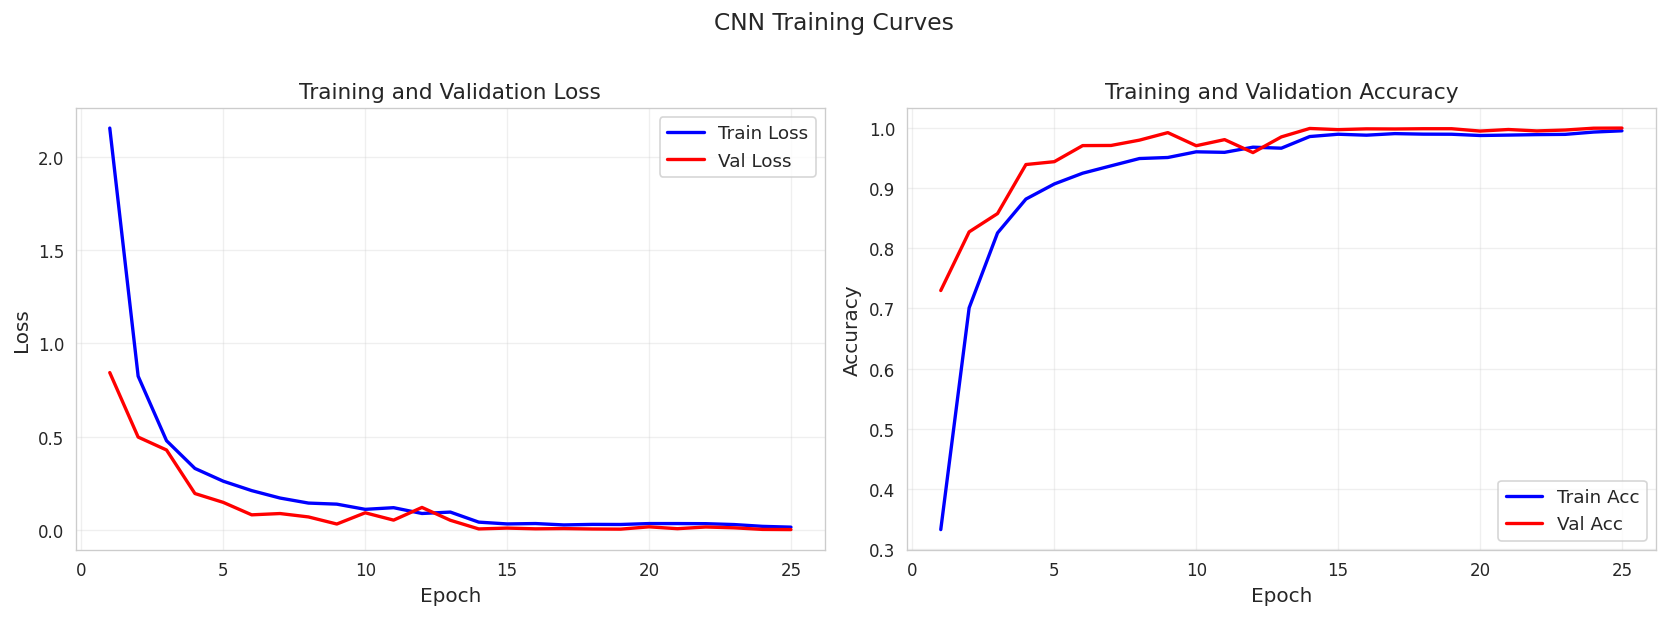

In [12]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Train Loss')
ax1.plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Val Loss')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['train_acc'], 'b-', linewidth=2, label='Train Acc')
ax2.plot(epochs, history['val_acc'], 'r-', linewidth=2, label='Val Acc')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle("CNN Training Curves", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("cnn_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()


In [13]:

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

y_pred_names = label_encoder.inverse_transform(y_pred)
y_true_names = label_encoder.inverse_transform(y_true)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("=" * 45)
print("   CNN - Test Set Results")
print("=" * 45)
print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")
print("=" * 45)


   CNN - Test Set Results
   Accuracy:  0.9983 (99.83%)
   Precision: 0.9983
   Recall:    0.9983
   F1-Score:  0.9983



Per-Class Classification Report:

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       200
           B       1.00      1.00      1.00       200
           C       1.00      1.00      1.00       200
           D       1.00      1.00      1.00       200
           E       0.99      1.00      0.99       200
           F       1.00      1.00      1.00       200
           G       1.00      1.00      1.00       200
           H       1.00      1.00      1.00       200
           I       1.00      0.98      0.99       200
           J       1.00      1.00      1.00       200
           K       1.00      1.00      1.00       200
           L       1.00      1.00      1.00       200
           M       0.99      0.99      0.99       200
           N       1.00      1.00      1.00       200
           O       1.00      1.00      1.00       200
           P       1.00      1.00      1.00       200
           Q       1.00      1.00      1.00   

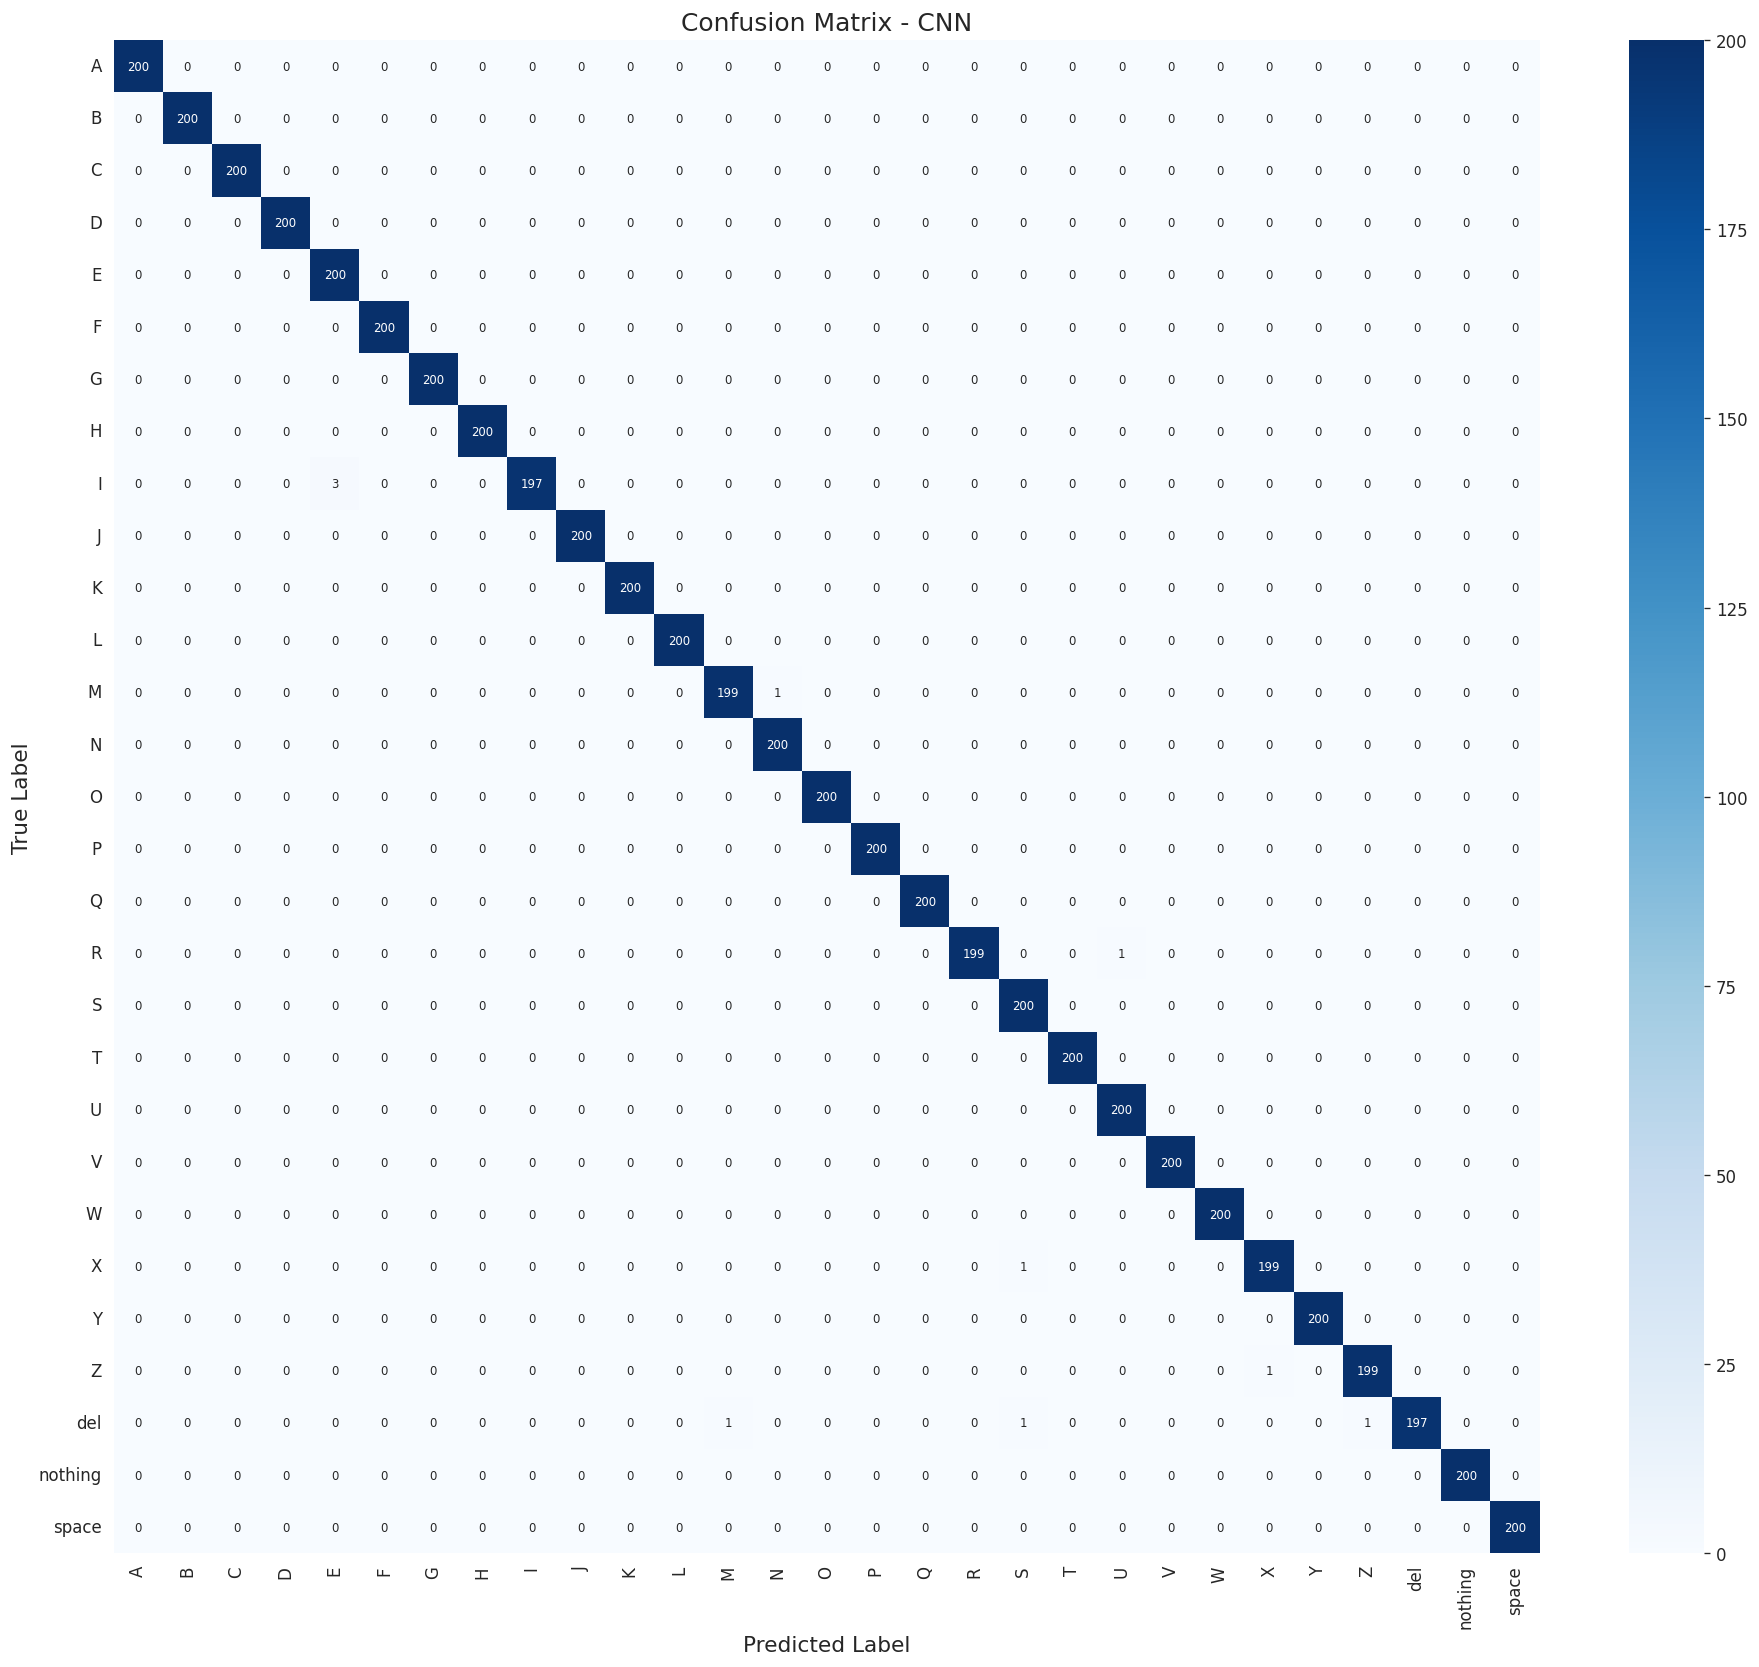

In [14]:

print("\nPer-Class Classification Report:\n")
print(classification_report(y_true_names, y_pred_names, target_names=class_names))

cm = confusion_matrix(y_true_names, y_pred_names, labels=class_names)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, annot_kws={"size": 7})
ax.set_xlabel("Predicted Label", fontsize=13)
ax.set_ylabel("True Label", fontsize=13)
ax.set_title("Confusion Matrix - CNN", fontsize=15)
plt.tight_layout()
plt.savefig("confusion_matrix_cnn.png", dpi=150, bbox_inches='tight')
plt.show()


Top 10 Most Confused Class Pairs:
----------------------------------------
  True:        I  ->  Predicted:        E  |  Count: 3
  True:        M  ->  Predicted:        N  |  Count: 1
  True:        R  ->  Predicted:        U  |  Count: 1
  True:        X  ->  Predicted:        S  |  Count: 1
  True:        Z  ->  Predicted:        X  |  Count: 1
  True:      del  ->  Predicted:        M  |  Count: 1
  True:      del  ->  Predicted:        S  |  Count: 1
  True:      del  ->  Predicted:        Z  |  Count: 1

Total misclassified: 10 / 5800


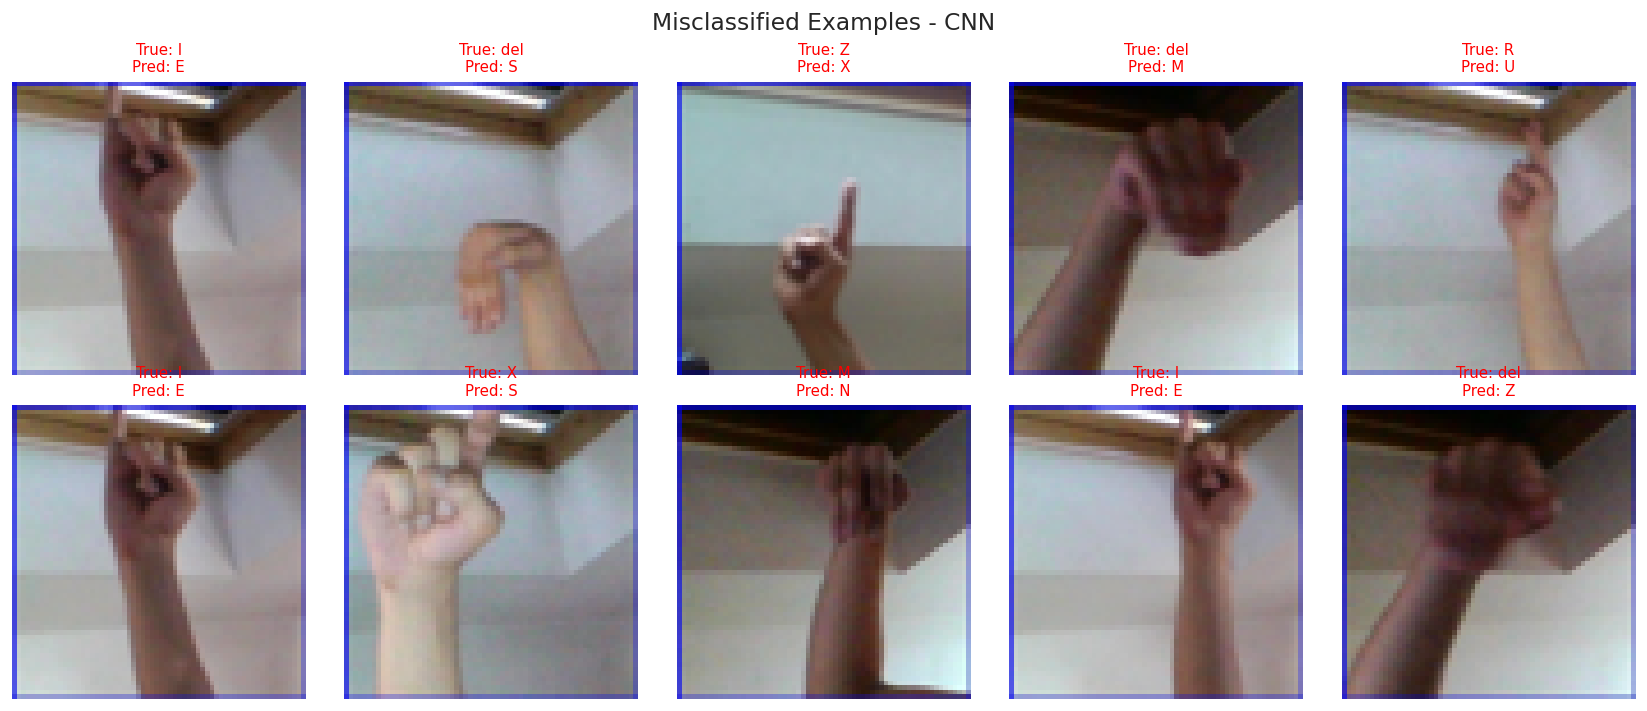

In [15]:

confusion_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i][j] > 0:
            confusion_pairs.append((class_names[i], class_names[j], cm[i][j]))

confusion_pairs.sort(key=lambda x: x[2], reverse=True)

print("Top 10 Most Confused Class Pairs:")
print("-" * 40)
for true_cls, pred_cls, count in confusion_pairs[:10]:
    print(f"  True: {true_cls:>8s}  ->  Predicted: {pred_cls:>8s}  |  Count: {count}")


misclassified_idx = np.where(y_pred != y_true)[0]
print(f"\nTotal misclassified: {len(misclassified_idx)} / {len(y_true)}")

num_show = min(10, len(misclassified_idx))
sample_idx = random.sample(list(misclassified_idx), num_show)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
for i, idx in enumerate(sample_idx):
    img = Image.open(paths_test[idx]).resize((IMG_SIZE, IMG_SIZE)).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(f"True: {label_encoder.inverse_transform([y_true[idx]])[0]}\n"
                      f"Pred: {label_encoder.inverse_transform([y_pred[idx]])[0]}",
                      fontsize=9, color='red')
    axes[i].axis('off')

plt.suptitle("Misclassified Examples - CNN", fontsize=14)
plt.tight_layout()
plt.savefig("misclassified_cnn.png", dpi=150, bbox_inches='tight')
plt.show()